# La Jolla Cove Species Identification — DINOv2 Baseline

Image classification model using transfer learning with DINOv2 (ViT-B/14) on an iNaturalist-derived dataset of species commonly found at La Jolla Cove.

**Approach**: Freeze the DINOv2 backbone and train a linear classification head. Set `FREEZE_BACKBONE = False` in config to enable full fine-tuning.

## 1. Setup and Imports

In [3]:
import os
import json
import copy
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast

import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
from PIL import Image

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    print("MPS (Apple Silicon) available")

PyTorch version: 2.6.0+cu118
Torchvision version: 0.21.0+cu118
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4070 Laptop GPU


### Configuration

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR = Path("data")               # root with train/ val/ test/ subdirs
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Model ──────────────────────────────────────────────────────────────────────
MODEL_NAME = "dinov2_vitb14"           # options: dinov2_vits14, dinov2_vitb14, dinov2_vitl14
IMAGE_SIZE = 224
FREEZE_BACKBONE = True                 # False = full fine-tuning

# ── Training ───────────────────────────────────────────────────────────────────
BATCH_SIZE = 32
LEARNING_RATE = 1e-3                   # higher LR is fine when only head is trained
LR_FINETUNE = 1e-5                     # used when FREEZE_BACKBONE is False
NUM_EPOCHS = 30
EARLY_STOP_PATIENCE = 5

# ── Hardware ───────────────────────────────────────────────────────────────────
NUM_WORKERS = 4
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
USE_AMP = DEVICE.type == "cuda"        # mixed precision only on CUDA

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
print(f"AMP enabled: {USE_AMP}")
print(f"Backbone frozen: {FREEZE_BACKBONE}")
print(f"Effective LR: {LEARNING_RATE if FREEZE_BACKBONE else LR_FINETUNE}")

Device: cuda
AMP enabled: True
Backbone frozen: True
Effective LR: 0.001


## 2. Dataset Loading and Inspection

In [5]:
# Load datasets with a basic ToTensor transform just for inspection.
# Real augmentation transforms are defined in Section 3.
_inspect_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset_raw = datasets.ImageFolder(DATA_DIR / "train", transform=_inspect_transform)
val_dataset_raw   = datasets.ImageFolder(DATA_DIR / "val",   transform=_inspect_transform)
test_dataset_raw  = datasets.ImageFolder(DATA_DIR / "test",  transform=_inspect_transform)

class_names = train_dataset_raw.classes
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}\n")

for split_name, ds in [("Train", train_dataset_raw), ("Val", val_dataset_raw), ("Test", test_dataset_raw)]:
    targets = [s[1] for s in ds.samples]
    counts = Counter(targets)
    print(f"  {split_name}: {len(ds)} images")
    for idx in sorted(counts):
        print(f"    {ds.classes[idx]:>30s}: {counts[idx]}")
    print()

Number of classes: 40
Class names: ['Actitis_macularius', 'Arenaria_melanocephala', 'Argyranthemum_foeniculaceum', 'Calidris_minutilla', 'Carpobrotus_edulis', 'Columba_livia_domestica', 'Echium_candicans', 'Egretta_thula', 'Haematopus_bachmani', 'Haematopus_palliatus_×_bachmani', 'Hydroprogne_caspia', 'Isocoma_menziesii', 'Larus_californicus', 'Larus_delawarensis', 'Larus_heermanni', 'Larus_occidentalis', 'Limonium_perezii', 'Melaleuca_nesophila', 'Melanitta_perspicillata', 'Melospiza_melodia', 'Nannopterum_auritum', 'Nicotiana_glauca', 'Numenius_hudsonicus', 'Otospermophilus_beecheyi', 'Pandion_haliaetus', 'Passer_domesticus', 'Pelecanus_occidentalis', 'Pelecanus_occidentalis_californicus', 'Phoca_vitulina', 'Phoca_vitulina_richardii', 'Rissa_tridactyla', 'Sayornis_nigricans', 'Selasphorus_sasin', 'Thalasseus_elegans', 'Thalasseus_maximus', 'Tringa_incana', 'Tursiops_truncatus', 'Urile_pelagicus', 'Urile_penicillatus', 'Zalophus_californianus']

  Train: 8684 images
                Ac

### Sample images

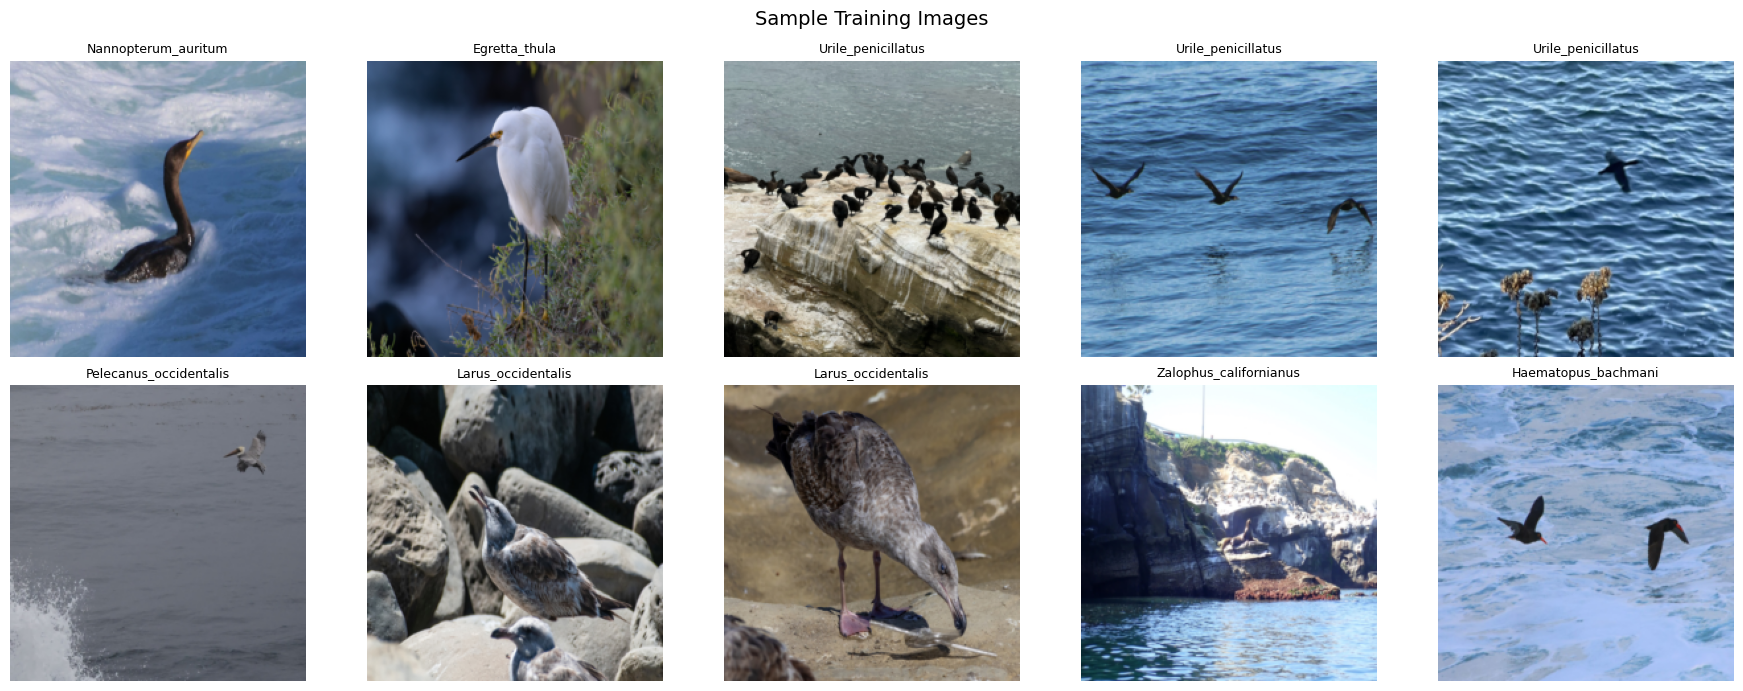

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
indices = random.sample(range(len(train_dataset_raw)), 10)
for ax, idx in zip(axes.flat, indices):
    img, label = train_dataset_raw[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")
fig.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Transforms and DataLoaders

In [7]:
# ImageNet normalization (used by DINOv2)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),   # 256 for IMAGE_SIZE=224
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [8]:
train_dataset = datasets.ImageFolder(DATA_DIR / "train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(DATA_DIR / "val",   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(DATA_DIR / "test",  transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 271
Val batches:   58
Test batches:  60


## 4. Model

Load a pretrained DINOv2 backbone from `torch.hub` and attach a linear classification head. The backbone is frozen by default (linear probing); set `FREEZE_BACKBONE = False` for full fine-tuning.

In [9]:
class DINOv2Classifier(nn.Module):
    """DINOv2 backbone + linear classification head."""

    def __init__(self, backbone, embed_dim: int, num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        self.backbone = backbone
        self.backbone_frozen = freeze_backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            self.backbone.eval()
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(self, x):
        if self.backbone_frozen:
            with torch.no_grad():
                features = self.backbone(x)
        else:
            features = self.backbone(x)
        return self.head(features)

In [10]:
# DINOv2 embed dims: vits14=384, vitb14=768, vitl14=1024
EMBED_DIMS = {"dinov2_vits14": 384, "dinov2_vitb14": 768, "dinov2_vitl14": 1024}

backbone = torch.hub.load("facebookresearch/dinov2", MODEL_NAME)
embed_dim = EMBED_DIMS[MODEL_NAME]

model = DINOv2Classifier(backbone, embed_dim, num_classes, freeze_backbone=FREEZE_BACKBONE)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:>12,}")
print(f"Trainable parameters: {trainable_params:>12,}")
print(f"Frozen parameters:    {total_params - trainable_params:>12,}")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to C:\Users\danie/.cache\torch\hub\main.zip
C:\Users\danie/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\danie/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\danie/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to C:\Users\danie/.cache\torch\hub\checkpoints\dinov2_vitb14_pretrain.pth
100%|██████████| 330M/330M [00:12<00:00, 27.7MB/s] 


Total parameters:       86,612,776
Trainable parameters:       32,296
Frozen parameters:      86,580,480


## 5. Training Setup

In [11]:
criterion = nn.CrossEntropyLoss()

lr = LEARNING_RATE if FREEZE_BACKBONE else LR_FINETUNE
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=lr, weight_decay=1e-2)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

scaler = GradScaler("cuda", enabled=USE_AMP)

print(f"Loss:      CrossEntropyLoss")
print(f"Optimizer: AdamW (lr={lr}, wd=1e-2)")
print(f"Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")
print(f"Scaler:    {'enabled' if USE_AMP else 'disabled'}")

Loss:      CrossEntropyLoss
Optimizer: AdamW (lr=0.001, wd=1e-2)
Scheduler: CosineAnnealingLR (T_max=30)
Scaler:    enabled


## 6. Training Loop

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, use_amp):
    model.train()
    # Keep backbone in eval mode when frozen (batchnorm / dropout)
    if FREEZE_BACKBONE:
        model.backbone.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda", enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device, use_amp):
    model.eval()
    running_loss = 0.0
    correct_top1 = 0
    correct_top3 = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with autocast("cuda", enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)

        _, preds_top1 = outputs.max(1)
        correct_top1 += preds_top1.eq(labels).sum().item()

        # Top-3 accuracy
        _, preds_top3 = outputs.topk(min(3, outputs.size(1)), dim=1)
        correct_top3 += preds_top3.eq(labels.unsqueeze(1)).any(1).sum().item()

    return running_loss / total, correct_top1 / total, correct_top3 / total

In [13]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [], "val_top3_acc": [],
}

best_val_acc = 0.0
best_model_wts = None
epochs_no_improve = 0

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>10}  {'Train Acc':>10}  {'Val Acc':>10}  {'Val Top3':>10}  {'LR':>10}  {'Time':>6}")
print("-" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE, USE_AMP)
    val_loss, val_acc, val_top3 = evaluate(model, val_loader, criterion, DEVICE, USE_AMP)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_top3_acc"].append(val_top3)

    elapsed = time.time() - t0
    current_lr = scheduler.get_last_lr()[0]

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        marker = " *"
    else:
        epochs_no_improve += 1

    print(f"{epoch:>5d}  {train_loss:>10.4f}  {val_loss:>10.4f}  {train_acc:>10.4f}  {val_acc:>10.4f}  {val_top3:>10.4f}  {current_lr:>10.2e}  {elapsed:>5.1f}s{marker}")

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch  Train Loss    Val Loss   Train Acc     Val Acc    Val Top3          LR    Time
-------------------------------------------------------------------------------------
    1      0.4751      0.2599      0.8789      0.9160      0.9881    9.97e-04   58.5s *
    2      0.2071      0.2050      0.9381      0.9339      0.9913    9.89e-04   61.5s *
    3      0.1661      0.1959      0.9485      0.9393      0.9913    9.76e-04   63.7s *
    4      0.1508      0.1976      0.9511      0.9426      0.9902    9.57e-04   61.6s *
    5      0.1291      0.2003      0.9571      0.9323      0.9913    9.33e-04   60.4s
    6      0.1223      0.1889      0.9593      0.9491      0.9913    9.05e-04   60.6s *
    7      0.1093      0.1867      0.9638      0.9475      0.9908    8.72e-04   60.7s
    8      0.1063      0.1874      0.9649      0.9458      0.9892    8.35e-04   59.4s
    9      0.0920      0.2001      0.9706      0.9475      0.9908    7.94e-04   60.1s
   10      0.0950      0.1985      0.9705   

### Training curves

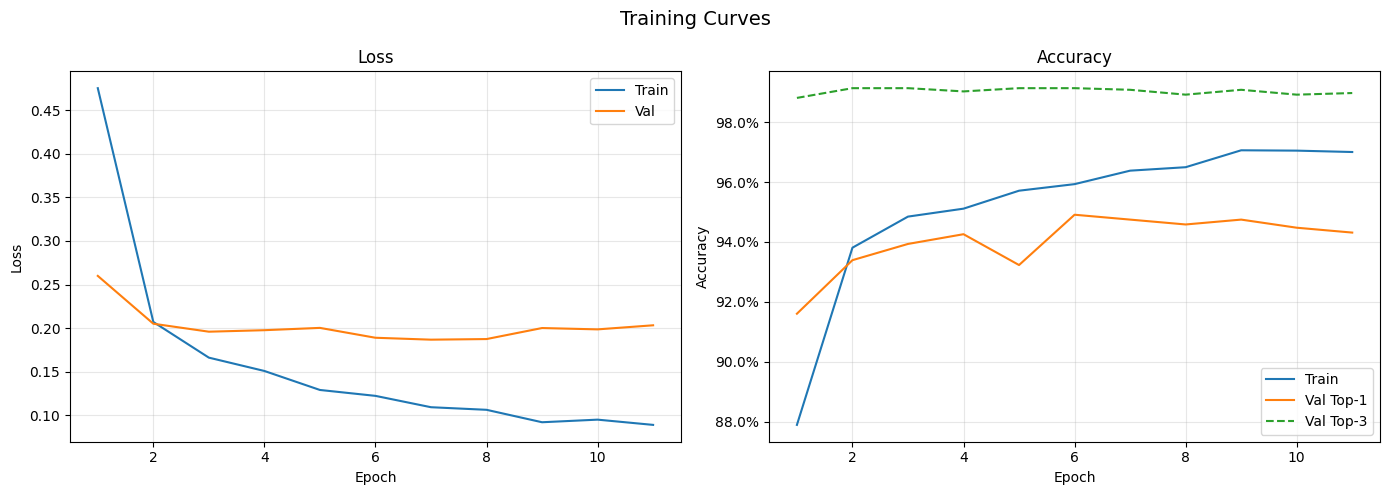

Saved training curves to outputs\training_curves.png


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs_range, history["train_loss"], label="Train")
ax1.plot(epochs_range, history["val_loss"], label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_acc"], label="Train")
ax2.plot(epochs_range, history["val_acc"], label="Val Top-1")
ax2.plot(epochs_range, history["val_top3_acc"], label="Val Top-3", linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

fig.suptitle("Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved training curves to {OUTPUT_DIR / 'training_curves.png'}")

## 7. Evaluation on Test Set

In [15]:
# Restore best model weights
model.load_state_dict(best_model_wts)
model.eval()

test_loss, test_top1, test_top3 = evaluate(model, test_loader, criterion, DEVICE, USE_AMP)
print(f"Test Loss:         {test_loss:.4f}")
print(f"Test Top-1 Acc:    {test_top1:.4f}")
print(f"Test Top-3 Acc:    {test_top3:.4f}")

Test Loss:         0.2135
Test Top-1 Acc:    0.9318
Test Top-3 Acc:    0.9932


### Classification report and confusion matrix

In [16]:
@torch.no_grad()
def collect_predictions(model, loader, device, use_amp):
    """Collect all predictions and true labels from a DataLoader."""
    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        with autocast("cuda", enabled=use_amp):
            outputs = model(images)
        probs = torch.softmax(outputs.float(), dim=1)
        all_labels.append(labels)
        all_preds.append(outputs.argmax(1).cpu())
        all_probs.append(probs.cpu())

    return (torch.cat(all_labels).numpy(),
            torch.cat(all_preds).numpy(),
            torch.cat(all_probs).numpy())

y_true, y_pred, y_probs = collect_predictions(model, test_loader, DEVICE, USE_AMP)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

Classification Report:

                                     precision    recall  f1-score   support

                 Actitis_macularius      1.000     1.000     1.000        11
             Arenaria_melanocephala      0.963     0.867     0.912        30
        Argyranthemum_foeniculaceum      1.000     1.000     1.000         4
                 Calidris_minutilla      0.833     1.000     0.909         5
                 Carpobrotus_edulis      1.000     1.000     1.000        10
            Columba_livia_domestica      1.000     0.950     0.974        20
                   Echium_candicans      1.000     1.000     1.000         4
                      Egretta_thula      0.867     0.867     0.867        15
                Haematopus_bachmani      1.000     0.980     0.990        51
    Haematopus_palliatus_×_bachmani      1.000     1.000     1.000         4
                 Hydroprogne_caspia      1.000     0.500     0.667         4
                  Isocoma_menziesii      1.000     

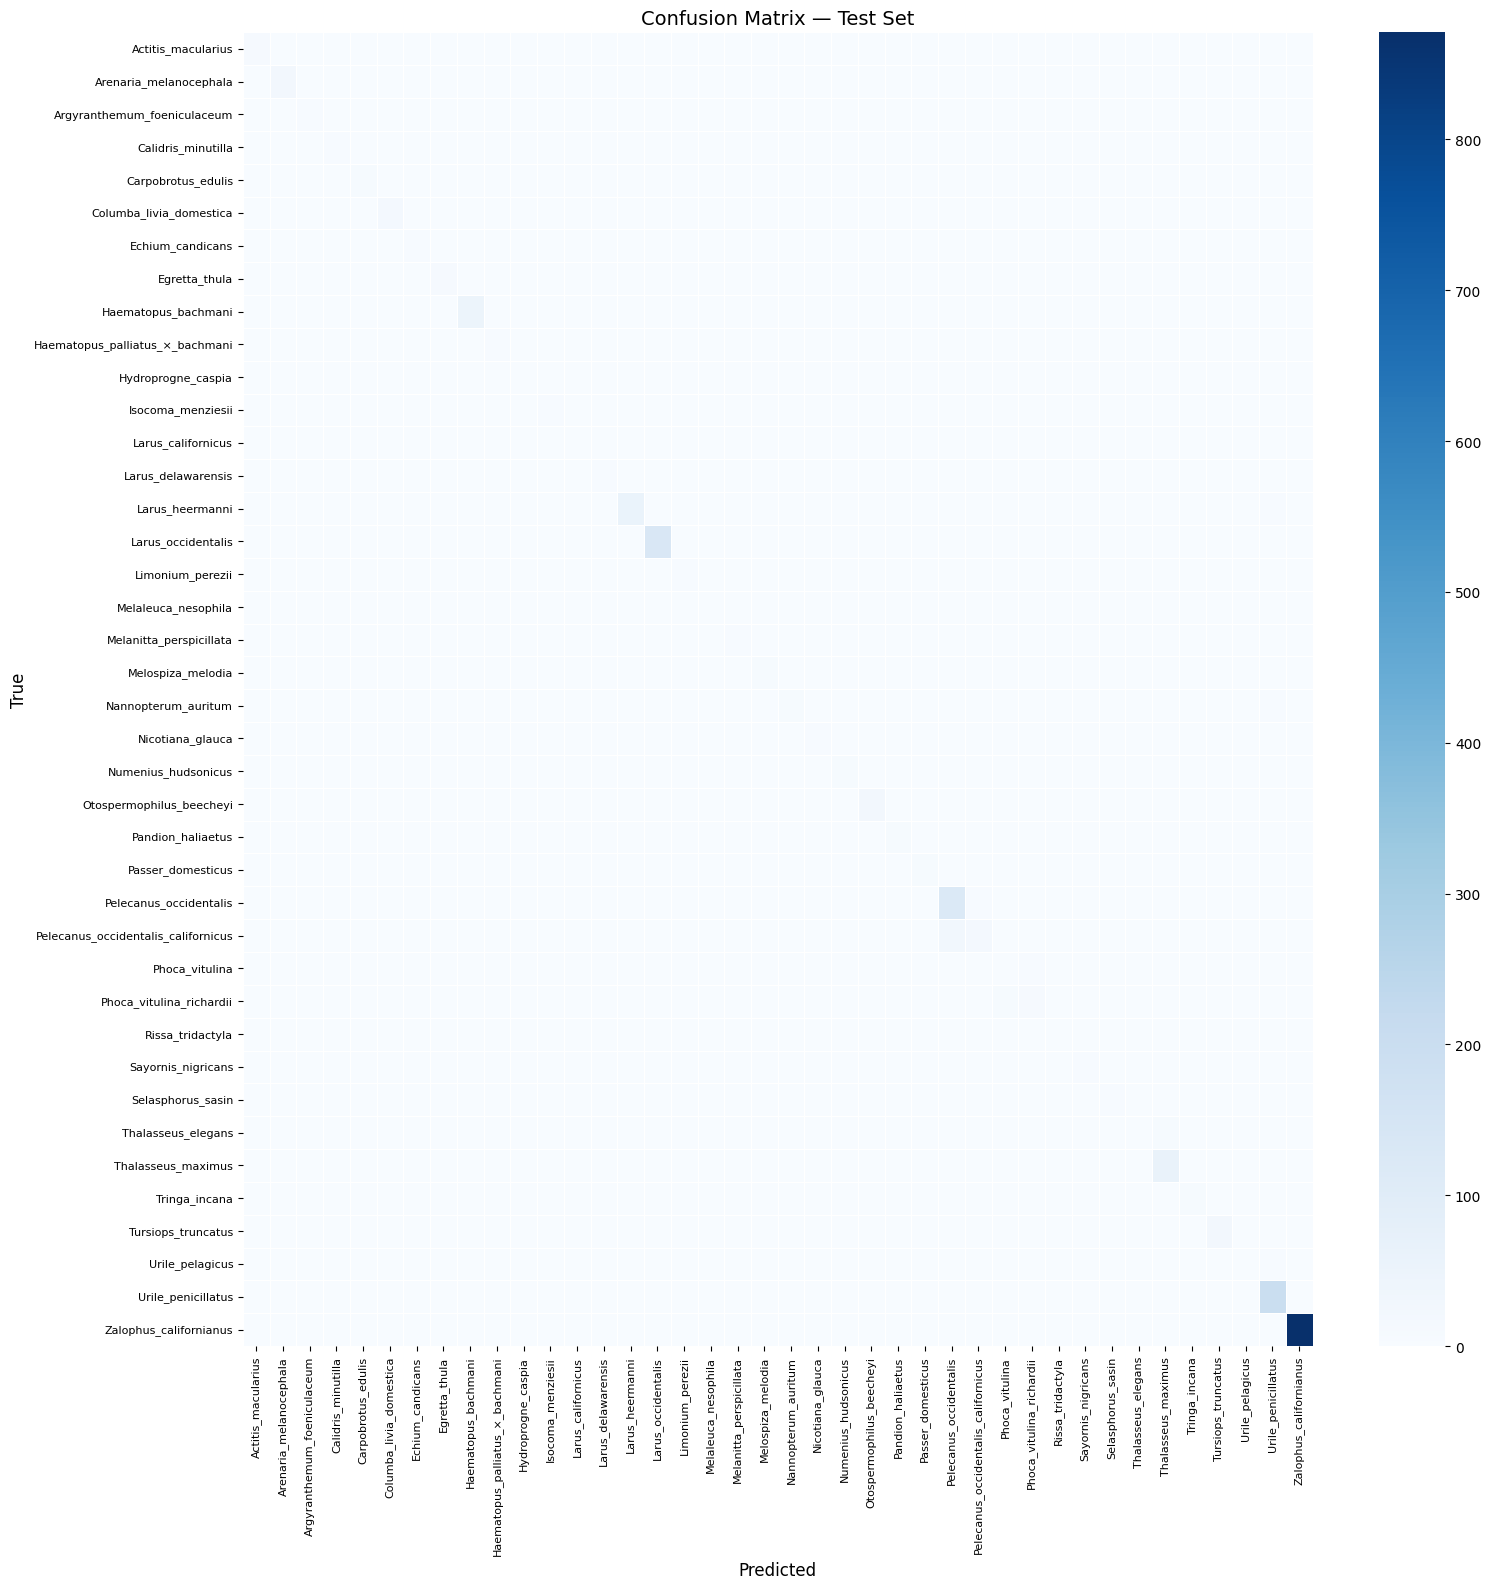

sklearn top-3 accuracy (verification): 0.9932


In [17]:
cm = confusion_matrix(y_true, y_pred)

# Adaptive figure size based on number of classes
fig_size = max(10, num_classes * 0.4)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(cm, annot=num_classes <= 30, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix — Test Set", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Also show sklearn top-k accuracy using probability matrix
if num_classes >= 3:
    sk_top3 = top_k_accuracy_score(y_true, y_probs, k=3, labels=range(num_classes))
    print(f"sklearn top-3 accuracy (verification): {sk_top3:.4f}")

## 8. Prediction on a Single Image

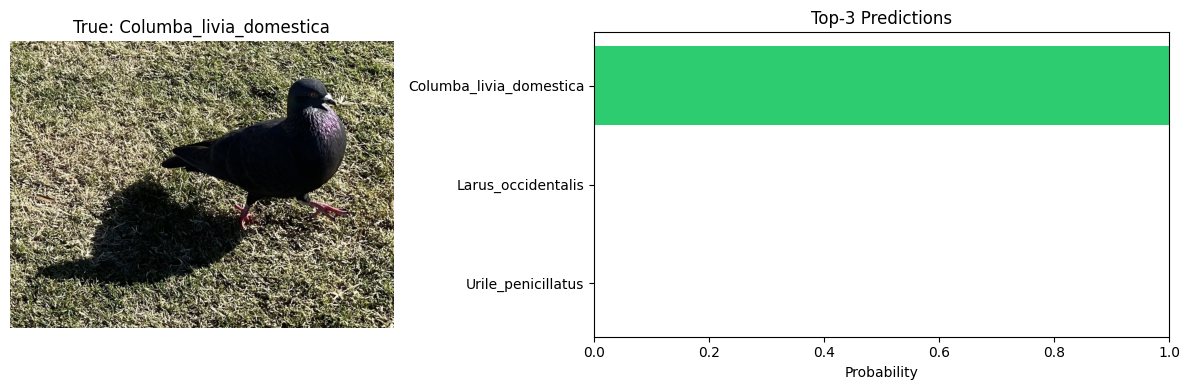

  #1: Columba_livia_domestica        1.0000
  #2: Larus_occidentalis             0.0000
  #3: Urile_penicillatus             0.0000


In [18]:
@torch.no_grad()
def predict_single_image(image_path, model, transform, class_names, device, top_k=3):
    """Run inference on a single image and return top-k predictions."""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with autocast("cuda", enabled=USE_AMP):
        logits = model(img_tensor)
    probs = torch.softmax(logits.float(), dim=1).squeeze(0)

    top_probs, top_indices = probs.topk(top_k)
    results = [(class_names[idx], prob.item()) for idx, prob in zip(top_indices, top_probs)]
    return img, results


# Pick a random test image for demonstration
sample_path, sample_label = test_dataset.samples[random.randint(0, len(test_dataset) - 1)]
true_name = class_names[sample_label]

img, predictions = predict_single_image(sample_path, model, val_test_transforms, class_names, DEVICE, top_k=3)

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1.5]})

ax_img.imshow(img)
ax_img.set_title(f"True: {true_name}", fontsize=12)
ax_img.axis("off")

names = [p[0] for p in predictions]
probs = [p[1] for p in predictions]
colors = ["#2ecc71" if n == true_name else "#3498db" for n in names]
ax_bar.barh(range(len(names)), probs, color=colors)
ax_bar.set_yticks(range(len(names)))
ax_bar.set_yticklabels(names, fontsize=10)
ax_bar.set_xlabel("Probability")
ax_bar.set_title("Top-3 Predictions")
ax_bar.set_xlim(0, 1)
ax_bar.invert_yaxis()

plt.tight_layout()
plt.show()

for rank, (name, prob) in enumerate(predictions, 1):
    print(f"  #{rank}: {name:<30s} {prob:.4f}")

## 9. Saving Artifacts

In [19]:
# ── 1. Best model checkpoint ───────────────────────────────────────────────────
checkpoint_path = OUTPUT_DIR / "best_model.pth"
torch.save({
    "model_state_dict": best_model_wts,
    "model_name": MODEL_NAME,
    "num_classes": num_classes,
    "class_names": class_names,
    "image_size": IMAGE_SIZE,
    "freeze_backbone": FREEZE_BACKBONE,
    "best_val_acc": best_val_acc,
}, checkpoint_path)
print(f"Saved model checkpoint: {checkpoint_path}")

# ── 2. Class names ─────────────────────────────────────────────────────────────
class_names_path = OUTPUT_DIR / "class_names.json"
with open(class_names_path, "w") as f:
    json.dump(class_names, f, indent=2)
print(f"Saved class names:     {class_names_path}")

# ── 3. Metrics ─────────────────────────────────────────────────────────────────
metrics = {
    "best_val_acc": best_val_acc,
    "test_top1_acc": test_top1,
    "test_top3_acc": test_top3,
    "test_loss": test_loss,
    "num_epochs_trained": len(history["train_loss"]),
    "model_name": MODEL_NAME,
    "freeze_backbone": FREEZE_BACKBONE,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": lr,
    "history": history,
}
metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Saved metrics:         {metrics_path}")

# ── 4. Training curves image was already saved in Section 6 ────────────────────
print(f"Training curves:       {OUTPUT_DIR / 'training_curves.png'}")
print("\nAll artifacts saved.")

Saved model checkpoint: outputs\best_model.pth
Saved class names:     outputs\class_names.json
Saved metrics:         outputs\metrics.json
Training curves:       outputs\training_curves.png

All artifacts saved.


## Summary

Artifacts saved to `outputs/`:
- `best_model.pth` — model checkpoint (state dict + metadata)
- `class_names.json` — ordered list of species class names
- `metrics.json` — all training/evaluation metrics and history
- `training_curves.png` — loss and accuracy plots

**Next steps:**
- Add metadata features (lat/lon, month) as additional inputs
- Try unfreezing the backbone (`FREEZE_BACKBONE = False`) for full fine-tuning
- Experiment with larger DINOv2 variants (`dinov2_vitl14`)
- Add test-time augmentation (TTA) for better predictions